# Two-Stage Fine-Tuning of REVE on PhysioNet Motor Imagery



## Strategy: Linear Probing → Per-Subject LoRA

| Stage | What trains | Data | Goal |
|-------|------------|------|------|
| **Stage 1 — Linear Probing (LP)** | Classification head only (backbone frozen) | All subjects pooled | Learn a robust, subject-agnostic classifier on top of REVE's pretrained features |
| **Stage 2 — Subject-Specific LoRA** | Low-Rank Adapters injected into the backbone + head | Each subject independently | Adapt the shared backbone to each subject's neural signature while keeping the bulk of the weights frozen |

## PhysioNet vs BCI-IV-2a

| Aspect | BCI-IV-2a | PhysioNet-MI |
|--------|-----------|--------|
| Dataset | `BNCI2014_001` (9 subjects, 22 ch) | `PhysionetMI` (109 subjects, 64 ch) |
| Channels used | 22 motor-cortex channels | Same 22 (selected from 64) |
| Sampling rate | 250 Hz | 200 Hz (gives 3 clean patches of 200 from 3 s epochs) |
| Time patches | 5 | 3 |
| Classes | left hand, right hand, feet, tongue | left hand, right hand, feet, hands |
| Subjects evaluated | 9 (all) | 10 (configurable subset of 109) |

## 1 — Load REVE from Hugging Face

The model is gated, so you need to accept the licence on the [Hugging Face collection](https://huggingface.co/collections/brain-bzh/reve) first.

In [ ]:
from huggingface_hub import login

HF_TOKEN = "INSERT8YOUR_HF_TOKEN_HARE BLABLABLABLABLABLABLA"

login(token=HF_TOKEN)
print("Login successful.")

Login successful.


In [ ]:
from transformers import AutoModel
import torch

model = AutoModel.from_pretrained(
    "brain-bzh/reve-base", trust_remote_code=True, torch_dtype="auto", token=HF_TOKEN
)
pos_bank = AutoModel.from_pretrained(
    "brain-bzh/reve-positions", trust_remote_code=True, torch_dtype="auto", token=HF_TOKEN
)

print(model)

Loading weights: 100%|██████████| 1/1 [00:00<00:00, 3536.51it/s]

Reve(
  (transformer): TransformerBackbone(
    (layers): ModuleList(
      (0-21): 22 x ModuleList(
        (0): Attention(
          (norm): RMSNorm()
          (to_qkv): Linear(in_features=512, out_features=1536, bias=False)
          (to_out): Linear(in_features=512, out_features=512, bias=False)
          (attend): FlashAttention()
        )
        (1): FeedForward(
          (net): Sequential(
            (0): RMSNorm()
            (1): Linear(in_features=512, out_features=2722, bias=False)
            (2): GEGLU()
            (3): Linear(in_features=1361, out_features=512, bias=False)
          )
        )
      )
    )
  )
  (to_patch_embedding): Sequential(
    (0): Linear(in_features=200, out_features=512, bias=True)
  )
  (fourier4d): FourierEmb4D()
  (mlp4d): Sequential(
    (0): Linear(in_features=4, out_features=512, bias=False)
    (1): GELU(approximate='none')
    (2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  )
  (ln): LayerNorm((512,), eps=1e-05, elemen

## 2 — Hyperparameters

We select the same **22 motor-cortex channels** that exist in BCI-IV-2a. All 22 are present in PhysioNet-MI's 64-channel montage (after MNE's `eegbci.standardize()` normalises channel names to the 10-10 convention).

The sampling rate is **200 Hz** (instead of 250 Hz for BCI-IV-2a) because PhysioNet-MI epochs are 3 seconds long (the dataset's default interval), and `3 s × 200 Hz = 600 samples = 3 patches × 200`. This keeps the time dimension a clean multiple of the REVE patch size (200).

**Stage 1 (LP)** and **Stage 2 (LoRA)** use the same learning rates and LoRA configuration as the BCI-IV-2a

In [ ]:
BATCH_SIZE = 64
SEED = 42
NUM_SUBJECTS = 10

# Stage 1 — Linear Probing (all subjects)
LP_EPOCHS = 20
LP_LR = 1e-3

# Stage 2 — Per-subject LoRA fine-tuning
FT_EPOCHS = 15
FT_LR = 1e-4
LORA_RANK = 8
LORA_APPLY_TO = ("patch", "mlp4d", "attention", "ffn")

RESAMPLE_FREQ = 200
PATCH_SIZE = 200
EPOCH_DURATION = 3  # seconds (PhysioNet-MI default interval)
N_CLASSES = 4

TIME_PATCHES = (RESAMPLE_FREQ * EPOCH_DURATION) // PATCH_SIZE  # 3

MI_CHANNELS = [
    "Fz", "FC3", "FC1", "FCz", "FC2", "FC4",
    "C5", "C3", "C1", "Cz", "C2", "C4", "C6",
    "CP3", "CP1", "CPz", "CP2", "CP4",
    "P1", "Pz", "P2", "POz",
]

positions = pos_bank(MI_CHANNELS)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Channels: {len(MI_CHANNELS)}, Time patches: {TIME_PATCHES}, "
      f"Hidden dim: 512 → flat dim: {len(MI_CHANNELS) * TIME_PATCHES * 512}")

Device: cuda
Channels: 22, Time patches: 3, Hidden dim: 512 → flat dim: 33792


### Classification head

The REVE base model outputs shape `[B, C, T, 512]` where C = number of channels and T = number of time patches. With 22 channels and 3 time patches: `[B, 22, 3, 512]`. We flatten and project to 4 classes.

In [ ]:
dim = len(MI_CHANNELS) * TIME_PATCHES * 512

model.final_layer = torch.nn.Sequential(
    torch.nn.Flatten(),
    torch.nn.RMSNorm(dim),
    torch.nn.Dropout(0.1),
    torch.nn.Linear(dim, N_CLASSES),
)
print(f"Classification head input dim: {dim}")

Classification head input dim: 33792


In [ ]:
from transformers import set_seed

set_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## 3 — Load PhysioNet Motor Imagery

We load the dataset from MOABB (`PhysionetMI`, 109 subjects, 64 EEG channels, 4 motor-imagery classes).

We resample to **200 Hz** and select only the **22 motor-cortex channels** matching the BCI-IV-2a montage. MOABB's `channels` parameter handles the selection after MNE's `eegbci.standardize()` normalises channel names.

Each subject's data is split 70 / 15 / 15 into train / val / test, and the pooled loaders are the union of all subject-level splits.

In [ ]:
import socket
from functools import partial
from moabb.datasets import PhysionetMI
from moabb.paradigms import MotorImagery
from scipy.signal import butter, lfilter
import numpy as np
from torch.utils.data import Dataset, DataLoader, Subset, ConcatDataset

SUBJECTS = list(range(1, NUM_SUBJECTS + 1))

# PhysioNet downloads can be slow — raise the global socket timeout (default is 30 s)
_prev_timeout = socket.getdefaulttimeout()
socket.setdefaulttimeout(300)  # 5 minutes


def butter_bandpass(lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    return butter(order, [low, high], btype="band")


paradigm = MotorImagery(
    n_classes=N_CLASSES, resample=RESAMPLE_FREQ, fmin=8, fmax=30, channels=MI_CHANNELS
)
mi_dataset = PhysionetMI()

# Download subject-by-subject with retries to avoid a single timeout killing everything
import time

all_X, all_y, all_meta = [], [], []
for subj in SUBJECTS:
    for attempt in range(3):
        try:
            Xi, yi, mi = paradigm.get_data(dataset=mi_dataset, subjects=[subj])
            all_X.append(Xi)
            all_y.append(yi)
            all_meta.append(mi)
            print(f"  Subject {subj}: {len(yi)} trials ✓")
            break
        except Exception as e:
            print(f"  Subject {subj} attempt {attempt+1} failed: {e}")
            if attempt < 2:
                time.sleep(5)
            else:
                raise

import pandas as _pd_tmp
X = np.concatenate(all_X, axis=0)
y_raw = np.concatenate(all_y, axis=0)
metadata = _pd_tmp.concat(all_meta, ignore_index=True)
del all_X, all_y, all_meta, _pd_tmp

socket.setdefaulttimeout(_prev_timeout)

# Truncate to the nearest clean multiple of PATCH_SIZE
n_samples = X.shape[-1]
usable = (n_samples // PATCH_SIZE) * PATCH_SIZE
X = X[:, :, :usable]
actual_patches = usable // PATCH_SIZE
print(f"Raw samples per trial: {n_samples} → truncated to {usable} "
      f"({actual_patches} patches of {PATCH_SIZE})")

if actual_patches != TIME_PATCHES:
    TIME_PATCHES = actual_patches
    dim = len(MI_CHANNELS) * TIME_PATCHES * 512
    model.final_layer = torch.nn.Sequential(
        torch.nn.Flatten(),
        torch.nn.RMSNorm(dim),
        torch.nn.Dropout(0.1),
        torch.nn.Linear(dim, N_CLASSES),
    )
    print(f"Rebuilt classification head for {TIME_PATCHES} patches (dim={dim})")

b, a = butter_bandpass(8, 30, RESAMPLE_FREQ)
X = lfilter(b, a, X, axis=-1)

label_map = {"left_hand": 0, "right_hand": 1, "feet": 2, "hands": 3}

# Filter out any non-MI labels (e.g. "rest") that the paradigm may return
keep = np.array([str(label) in label_map for label in y_raw])
X = X[keep]
y_raw = y_raw[keep]
metadata = metadata[keep].reset_index(drop=True)
print(f"Kept {keep.sum()}/{len(keep)} trials (dropped {(~keep).sum()} non-MI trials)")

y = np.array([label_map[str(label)] for label in y_raw])

subjects = sorted(metadata["subject"].unique())
print(f"Subjects: {subjects}  —  total trials: {len(y)}")


class MIDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return {"data": self.X[idx], "labels": self.y[idx]}


def collate_fn(batch, positions):
    x = torch.stack([b["data"] for b in batch])
    y = torch.tensor([b["labels"] for b in batch])
    pos = positions.repeat(len(batch), 1, 1)
    return {"sample": x, "label": y.long(), "pos": pos}


def make_loaders(dataset, batch_size, positions):
    """70/15/15 split → train/val/test DataLoaders."""
    n = len(dataset)
    n_train = int(0.7 * n)
    n_val = int(0.15 * n)
    n_test = n - n_train - n_val

    gen = torch.Generator().manual_seed(SEED)
    train_ds, val_ds, test_ds = torch.utils.data.random_split(
        dataset, [n_train, n_val, n_test], generator=gen
    )
    cfn = partial(collate_fn, positions=positions)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=cfn)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=cfn)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, collate_fn=cfn)
    return train_loader, val_loader, test_loader


# ---- Per-subject datasets ------------------------------------------------
subject_datasets = {}
for subj in subjects:
    mask = (metadata["subject"].values == subj)
    subject_datasets[subj] = MIDataset(X[mask], y[mask])
    print(f"  Subject {subj}: {mask.sum()} trials")

# ---- Pooled dataset (union of all subjects) --------------------------------
full_dataset = MIDataset(X, y)
pooled_train, pooled_val, pooled_test = make_loaders(full_dataset, BATCH_SIZE, positions)
print(f"\nPooled loaders — train: {len(pooled_train.dataset)}, "
      f"val: {len(pooled_val.dataset)}, test: {len(pooled_test.dataset)}")

Choosing from all possible events


Used Annotations descriptions: [np.str_('left_hand'), np.str_('rest'), np.str_('right_hand')]
Used Annotations descriptions: [np.str_('left_hand'), np.str_('rest'), np.str_('right_hand')]
Used Annotations descriptions: [np.str_('left_hand'), np.str_('rest'), np.str_('right_hand')]
Used Annotations descriptions: [np.str_('feet'), np.str_('hands'), np.str_('rest')]
Used Annotations descriptions: [np.str_('feet'), np.str_('hands'), np.str_('rest')]
Used Annotations descriptions: [np.str_('feet'), np.str_('hands'), np.str_('rest')]
  Subject 1: 174 trials ✓
Used Annotations descriptions: [np.str_('left_hand'), np.str_('rest'), np.str_('right_hand')]
Used Annotations descriptions: [np.str_('left_hand'), np.str_('rest'), np.str_('right_hand')]
Used Annotations descriptions: [np.str_('left_hand'), np.str_('rest'), np.str_('right_hand')]
Used Annotations descriptions: [np.str_('feet'), np.str_('hands'), np.str_('rest')]
Used Annotations descriptions: [np.str_('feet'), np.str_('hands'), np.str_

## 4 — Training and evaluation helpers

Same `train_one_epoch` / `eval_model` with AMP mixed-precision and six metrics as the BCI-IV-2a notebook.

In [ ]:
from tqdm.auto import tqdm
from sklearn.metrics import (
    balanced_accuracy_score,
    cohen_kappa_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)
from sklearn.preprocessing import label_binarize
import copy

criterion = torch.nn.CrossEntropyLoss()


def train_one_epoch(model, optimizer, loader):
    model.train()
    pbar = tqdm(loader, desc="Training", total=len(loader))
    device_type = "cuda" if torch.cuda.is_available() else "cpu"

    for batch_data in pbar:
        data = batch_data["sample"].to(device, non_blocking=True)
        target = batch_data["label"].to(device, non_blocking=True)
        pos = batch_data["pos"].to(device, non_blocking=True)

        optimizer.zero_grad()
        with torch.amp.autocast(dtype=torch.float16, device_type=device_type):
            output = model(data, pos)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})


def eval_model(model, loader):
    model.eval()
    device_type = "cuda" if torch.cuda.is_available() else "cpu"

    all_decisions, all_targets, all_probs = [], [], []
    score, count = 0, 0

    with torch.inference_mode():
        for batch_data in loader:
            data = batch_data["sample"].to(device, non_blocking=True)
            target = batch_data["label"].to(device, non_blocking=True)
            pos = batch_data["pos"].to(device, non_blocking=True)

            with torch.amp.autocast(dtype=torch.float16, device_type=device_type):
                output = model(data, pos)

            decisions = torch.argmax(output, dim=1)
            score += (decisions == target).int().sum().item()
            count += target.shape[0]
            all_decisions.append(decisions)
            all_targets.append(target)
            all_probs.append(output)

    gt = torch.cat(all_targets).cpu().numpy()
    pr = torch.cat(all_decisions).cpu().numpy()
    pr_probs = torch.softmax(torch.cat(all_probs).float(), dim=1).cpu().numpy()

    classes = list(range(N_CLASSES))

    acc = score / count
    balanced_acc = balanced_accuracy_score(gt, pr)
    kappa = cohen_kappa_score(gt, pr)
    f1 = f1_score(gt, pr, average="weighted")
    auroc = roc_auc_score(gt, pr_probs, multi_class="ovr")
    auc_pr = average_precision_score(
        label_binarize(gt, classes=classes), pr_probs, average="macro"
    )

    return {
        "acc": acc,
        "balanced_acc": balanced_acc,
        "cohen_kappa": kappa,
        "f1": f1,
        "auroc": auroc,
        "auc_pr": auc_pr,
    }

## 5 — Stage 1: Linear Probing on All Subjects

- The entire REVE backbone is **frozen** (`requires_grad=False`).
- Only the freshly initialized classification head (`final_layer`) is trained.
- We use **all subjects pooled** so the head learns a general mapping from REVE features to motor-imagery classes.
- Early stopping via `ReduceLROnPlateau` on validation balanced accuracy; we checkpoint the best head weights.

In [ ]:
for param in model.parameters():
    param.requires_grad = False
for param in model.final_layer.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Stage 1 — trainable: {trainable:,} / {total:,} ({100*trainable/total:.2f} %)")

model.to(device)

optimizer_lp = torch.optim.AdamW(model.final_layer.parameters(), lr=LP_LR)
scheduler_lp = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_lp, mode="max", factor=0.5, patience=3
)

best_val_acc = 0.0
best_head_state = None

for epoch in range(LP_EPOCHS):
    print(f"\n[LP] Epoch {epoch + 1}/{LP_EPOCHS}")
    train_one_epoch(model, optimizer_lp, pooled_train)
    metrics = eval_model(model, pooled_val)
    b_acc = metrics["balanced_acc"]
    if b_acc > best_val_acc:
        best_val_acc = b_acc
        best_head_state = copy.deepcopy(model.final_layer.state_dict())
    print(f"  val balanced_acc: {b_acc:.4f}  (best: {best_val_acc:.4f})")
    scheduler_lp.step(b_acc)

model.final_layer.load_state_dict(best_head_state)
lp_test = eval_model(model, pooled_test)
print(f"\n--- Stage 1 (LP) test results ---")
for k, v in lp_test.items():
    print(f"  {k}: {v:.4f}")

Stage 1 — trainable: 168,964 / 69,358,596 (0.24 %)

[LP] Epoch 1/20


Training: 100%|██████████| 10/10 [00:01<00:00,  8.05it/s, loss=5.4258]


  val balanced_acc: 0.2700  (best: 0.2700)

[LP] Epoch 2/20


Training: 100%|██████████| 10/10 [00:00<00:00, 14.69it/s, loss=2.4609]


  val balanced_acc: 0.2835  (best: 0.2835)

[LP] Epoch 3/20


...

  val balanced_acc: 0.2752  (best: 0.2919)

[LP] Epoch 19/20


Training: 100%|██████████| 10/10 [00:00<00:00, 14.83it/s, loss=0.0092]


  val balanced_acc: 0.2752  (best: 0.2919)

[LP] Epoch 20/20


Training: 100%|██████████| 10/10 [00:00<00:00, 14.69it/s, loss=0.0095]


  val balanced_acc: 0.2776  (best: 0.2919)

--- Stage 1 (LP) test results ---
  acc: 0.3037
  balanced_acc: 0.3006
  cohen_kappa: 0.0724
  f1: 0.3091
  auroc: 0.5466
  auc_pr: 0.2968


### Save the Stage-1 checkpoint

We deep-copy the full model state after LP. Every subject in Stage 2 will start from this exact checkpoint.

In [ ]:
lp_checkpoint = copy.deepcopy(model.state_dict())
print("Stage-1 checkpoint saved (in memory).")

Stage-1 checkpoint saved (in memory).


## 6 — Stage 2: Per-Subject LoRA Fine-Tuning

For each subject:

1. **Reload** the Stage-1 checkpoint.
2. **Inject LoRA adapters** into the backbone (`to_qkv`, `to_out`), rank 8, `lora_alpha = 16`.
3. **Fine-tune** on that subject's data alone (70/15/15 split).
4. **Evaluate** on the subject's held-out test set.

In [ ]:
from peft import LoraConfig, get_peft_model
import sys, types

sys.path.insert(0, "../reve-repro-main/src")


def apply_lora(base_model, rank=LORA_RANK):
    """Wrap the base REVE model with LoRA adapters and return the peft model."""
    lora_config = LoraConfig(
        r=rank,
        lora_alpha=2 * rank,
        target_modules=["to_qkv", "to_out"],
        lora_dropout=0.05,
        bias="none",
        modules_to_save=["final_layer"],
    )
    peft_model = get_peft_model(base_model, lora_config)
    return peft_model


_tmp = copy.deepcopy(model)
_tmp = apply_lora(_tmp)
_tmp.print_trainable_parameters()
del _tmp

trainable params: 709,636 || all params: 70,068,232 || trainable%: 1.0128


### Run Stage 2 loop over all subjects

In [ ]:
subject_results = {}

for subj in subjects:
    print(f"\n{'='*60}")
    print(f"  Stage 2 — Subject {subj}")
    print(f"{'='*60}")

    model.load_state_dict(lp_checkpoint)

    lora_model = apply_lora(model)
    lora_model.to(device)

    subj_train, subj_val, subj_test = make_loaders(
        subject_datasets[subj], BATCH_SIZE, positions
    )
    print(f"  Trials — train: {len(subj_train.dataset)}, "
          f"val: {len(subj_val.dataset)}, test: {len(subj_test.dataset)}")

    trainable_params = [p for p in lora_model.parameters() if p.requires_grad]
    optimizer_ft = torch.optim.AdamW(trainable_params, lr=FT_LR)
    scheduler_ft = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_ft, mode="max", factor=0.5, patience=3
    )

    best_val = 0.0
    best_state = None

    for epoch in range(FT_EPOCHS):
        print(f"\n  [FT-S{subj}] Epoch {epoch + 1}/{FT_EPOCHS}")
        train_one_epoch(lora_model, optimizer_ft, subj_train)
        m = eval_model(lora_model, subj_val)
        b_acc = m["balanced_acc"]
        if b_acc > best_val:
            best_val = b_acc
            best_state = copy.deepcopy(lora_model.state_dict())
        print(f"    val balanced_acc: {b_acc:.4f}  (best: {best_val:.4f})")
        scheduler_ft.step(b_acc)

    lora_model.load_state_dict(best_state)
    test_metrics = eval_model(lora_model, subj_test)
    subject_results[subj] = test_metrics

    print(f"\n  --- Subject {subj} test results ---")
    for k, v in test_metrics.items():
        print(f"    {k}: {v:.4f}")

    model = lora_model.merge_and_unload()

print("\nStage 2 complete for all subjects.")


  Stage 2 — Subject 1
  Trials — train: 62, val: 13, test: 15

  [FT-S1] Epoch 1/15


Training: 100%|██████████| 1/1 [00:00<00:00,  2.34it/s, loss=1.3438]


    val balanced_acc: 0.8750  (best: 0.8750)

  [FT-S1] Epoch 2/15


Training: 100%|██████████| 1/1 [00:00<00:00,  5.06it/s, loss=1.0361]


    val balanced_acc: 0.8750  (best: 0.8750)

  [FT-S1] Epoch 3/15


...

    val balanced_acc: 0.8125  (best: 0.8125)

  [FT-S10] Epoch 14/15


Training: 100%|██████████| 1/1 [00:00<00:00,  4.85it/s, loss=0.0361]


    val balanced_acc: 0.8125  (best: 0.8125)

  [FT-S10] Epoch 15/15


Training: 100%|██████████| 1/1 [00:00<00:00,  4.94it/s, loss=0.0331]

    val balanced_acc: 0.8125  (best: 0.8125)

  --- Subject 10 test results ---
    acc: 0.6667
    balanced_acc: 0.6726
    cohen_kappa: 0.5192
    f1: 0.6752
    auroc: 0.7872
    auc_pr: 0.7035

Stage 2 complete for all subjects.


## 7 — Results: Per-Subject Metrics & Volatility Analysis

We display:

1. A table of all 6 metrics for each subject.
2. **Mean and standard deviation** across subjects — a lower std indicates less volatility.

Compare with the BCI-IV-2a results to assess whether the two-stage technique transfers.

In [ ]:
import pandas as pd

rows = []
for subj in subjects:
    row = {"subject": subj}
    row.update(subject_results[subj])
    rows.append(row)

df = pd.DataFrame(rows).set_index("subject")

metric_cols = ["acc", "balanced_acc", "cohen_kappa", "f1", "auroc", "auc_pr"]
mean_row = df[metric_cols].mean()
std_row = df[metric_cols].std()

summary = pd.DataFrame([mean_row, std_row], index=["mean", "std"])
df_display = pd.concat([df[metric_cols], summary])

print("=" * 70)
print("  Two-Stage Fine-Tuning — Per-Subject Results (PhysioNet-MI)")
print("=" * 70)
print(df_display.round(4).to_string())
print()
print(f"Mean balanced accuracy: {mean_row['balanced_acc']:.4f} +/- {std_row['balanced_acc']:.4f}")
print(f"Mean Cohen's kappa:     {mean_row['cohen_kappa']:.4f} +/- {std_row['cohen_kappa']:.4f}")

  Two-Stage Fine-Tuning — Per-Subject Results (PhysioNet-MI)
         acc  balanced_acc  cohen_kappa      f1   auroc  auc_pr
1     0.9333        0.8750       0.9038  0.9248  0.9038  0.8958
2     0.7333        0.7417       0.6226  0.7363  0.7983  0.7745
3     0.7333        0.7292       0.6429  0.7336  0.8971  0.7826
4     0.9333        0.9375       0.9096  0.9352  0.9563  0.9208
5     0.7333        0.7417       0.6226  0.7407  0.9537  0.9643
6     0.9333        0.9583       0.9013  0.9370  1.0000  1.0000
7     0.5333        0.5375       0.3675  0.5505  0.7045  0.6002
8     0.9333        0.9375       0.9102  0.9333  1.0000  1.0000
9     0.8000        0.7708       0.7273  0.8059  0.9097  0.8431
10    0.6667        0.6726       0.5192  0.6752  0.7872  0.7035
mean  0.7933        0.7902       0.7127  0.7973  0.8911  0.8485
std   0.1386        0.1355       0.1909  0.1334  0.0981  0.1331

Mean balanced accuracy: 0.7902 +/- 0.1355
Mean Cohen's kappa:     0.7127 +/- 0.1909


### Visualisation: per-subject balanced accuracy

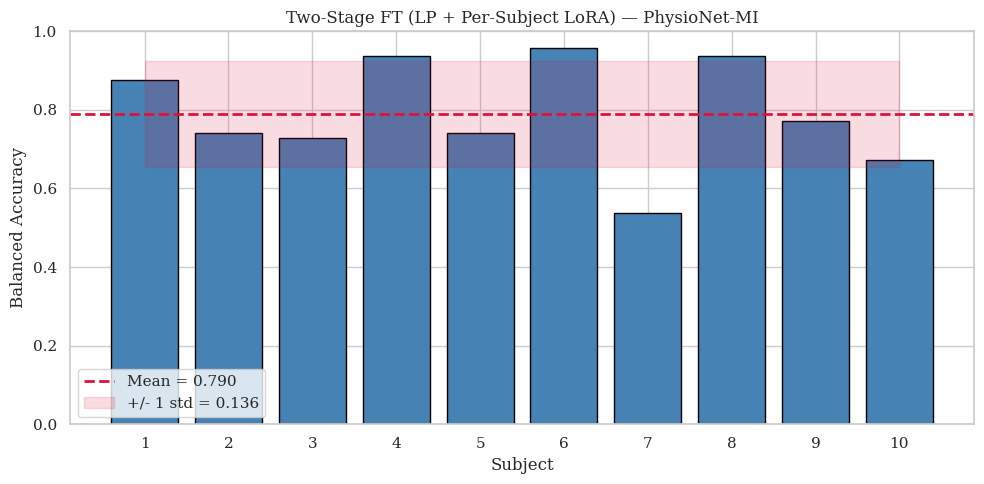

In [ ]:
try:
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(10, 5))
    subj_labels = [str(s) for s in subjects]
    bal_accs = [subject_results[s]["balanced_acc"] for s in subjects]
    bars = ax.bar(subj_labels, bal_accs, color="steelblue", edgecolor="black")
    ax.axhline(mean_row["balanced_acc"], color="crimson", linestyle="--", linewidth=2,
               label=f"Mean = {mean_row['balanced_acc']:.3f}")
    ax.fill_between(
        range(len(subjects)),
        mean_row["balanced_acc"] - std_row["balanced_acc"],
        mean_row["balanced_acc"] + std_row["balanced_acc"],
        alpha=0.15, color="crimson", label=f"+/- 1 std = {std_row['balanced_acc']:.3f}",
    )
    ax.set_xlabel("Subject")
    ax.set_ylabel("Balanced Accuracy")
    ax.set_title("Two-Stage FT (LP + Per-Subject LoRA) — PhysioNet-MI")
    ax.set_ylim(0, 1)
    ax.legend()
    plt.tight_layout()
    plt.show()
except ImportError:
    print("matplotlib not installed — skipping plot.")